In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("/content/Titanic.csv")

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df['age'] = df['Age'].fillna(df['Age'].mean())

In [ ]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'age'],
      dtype='object')

/tmp/ipykernel_2175/4156417718.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sex', palette='Set2')


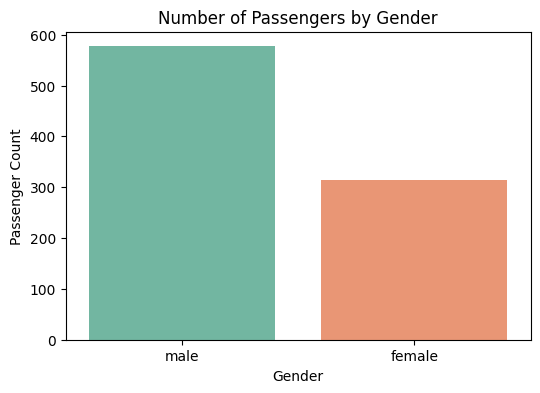

In [ ]:
# Q1. Create a countplot to show the number of passengers by gender.
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Sex', palette='Set2')
plt.title('Number of Passengers by Gender')
plt.xlabel('Gender')
plt.ylabel('Passenger Count')
plt.show()

this chart showa the total distribution of male and female on board. There were significantly more male passengers than female passengers on the Titanic.

/tmp/ipykernel_2175/2128705859.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Pclass', palette='Set2')


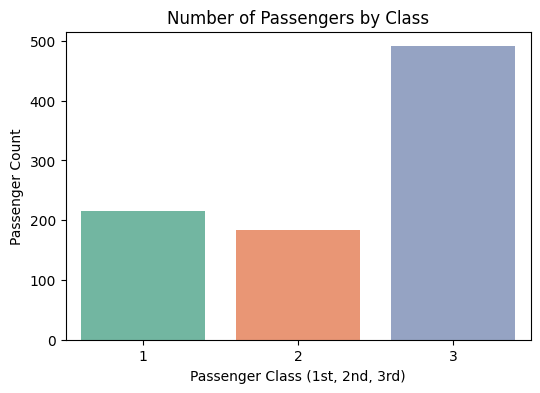

In [ ]:
# Q2. Create a bar chart to show the number of passengers in each passenger class using different colors.
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Pclass', palette='Set2')
plt.title('Number of Passengers by Class')
plt.xlabel('Passenger Class (1st, 2nd, 3rd)')
plt.ylabel('Passenger Count')
plt.show()

gthis charts interprets that majotity of the passegenrs travelled in the 3rd class  while the 1st and 2nd classes had significantly fewer passengers,with first class  passengers are slightly greter than the 2nd class.


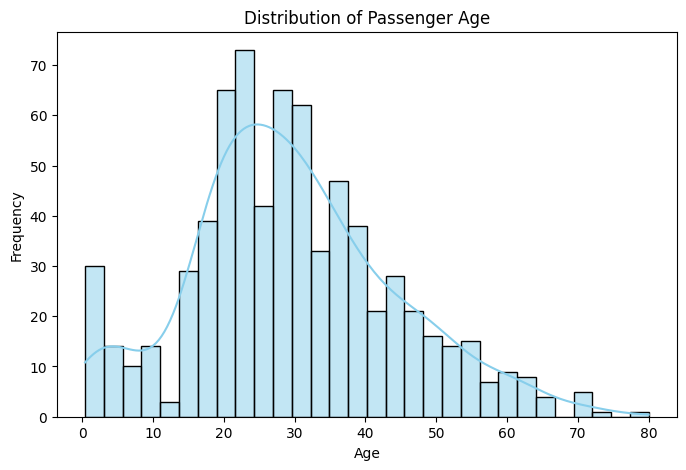

In [ ]:
# Q3. Create a histogram to show the distribution of passenger age
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', bins=30, kde=True, color='skyblue')
plt.title('Distribution of Passenger Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

this chart depicts that the age distribution is right skewed  showing that the majority of passengers were  adults of age ranging 20-40, while there is some small towers for infants/youung childrens of age range0-10


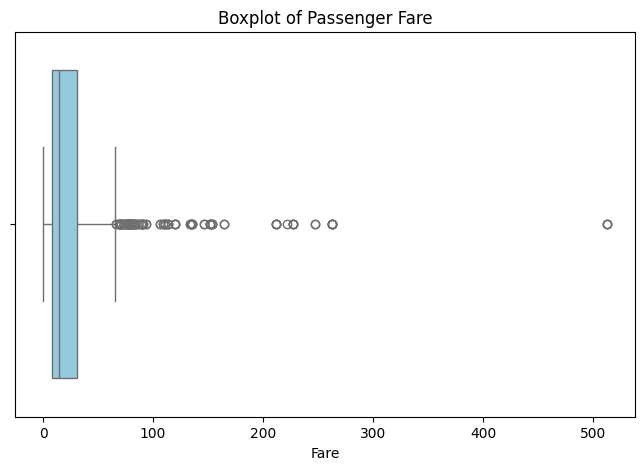

In [ ]:
#Q4:-  Create a boxplot to detect outliers in the fare column
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Fare', color='skyblue')
plt.title('Boxplot of Passenger Fare')
plt.xlabel('Fare')
plt.show()

The boxplot shows a highly dense distribution at lower fare amounts(under100$).
The single points extending far to the right indicate extreme outliers indicating a premium ticket fare price greater than 500 dollars.

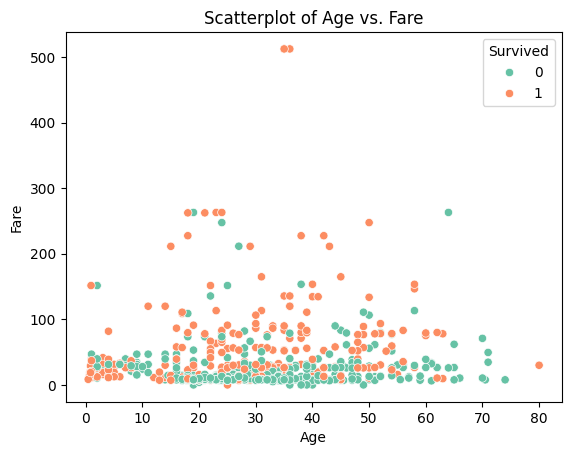

In [7]:
''' Q5. Create a scatterplot to
a. show the relationship between age and fare.'''
sns.scatterplot(data=df, x='Age', y='Fare', hue='Survived', palette='Set2')
plt.title('Scatterplot of Age vs. Fare')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()


there is no strong linear corelationship between age and fare. as passengers from all groups  generally bought lower-priced tickets.though a few high priced tickets are bought by adults of age approx40  or we can say that mostly yhe high priced ticket are bought primarilly by adults.

Text(0, 0.5, 'Fare')

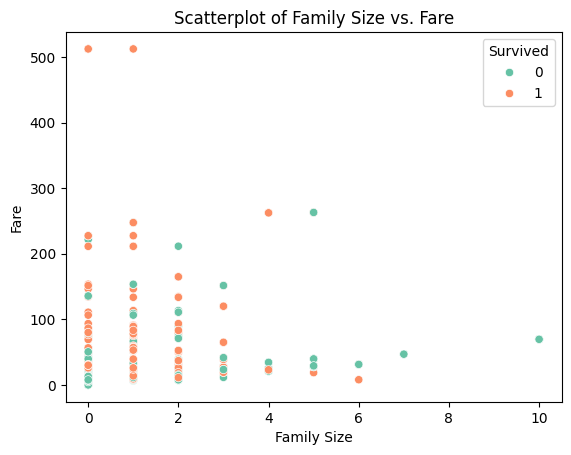

In [12]:
#5. b):-  to analyse the relation between  family size and fare
df["family_size"] = df["SibSp"] + df["Parch"]
sns.scatterplot(data=df, x='family_size', y='Fare', hue='Survived', palette='Set2')
plt.title('Scatterplot of Family Size vs. Fare')
plt.xlabel('Family Size')
plt.ylabel('Fare')

large families (family sizw>4)  preferred to travelled on lower to moderate fare tickets in comparison to those people who were travelling alone or with small family groups who paid the luxury fare.and the highest fare was paid by the people trsvelling alone.


In [10]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

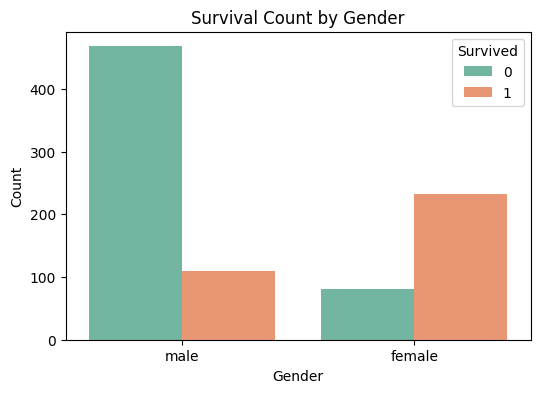

In [4]:
#Q6. Create a countplot to show survival count by gender
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Sex', hue='Survived', palette='Set2')
plt.title('Survival Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

even though the femaled on board counts seems to be less in comparison to mens but their survival count and rate is  drastically higher than mens could be a case where a kind of protocol were followed  of evacuting womens first than men.

/tmp/ipykernel_2055/1752191724.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Pclass', y='Survived', palette='Set2')


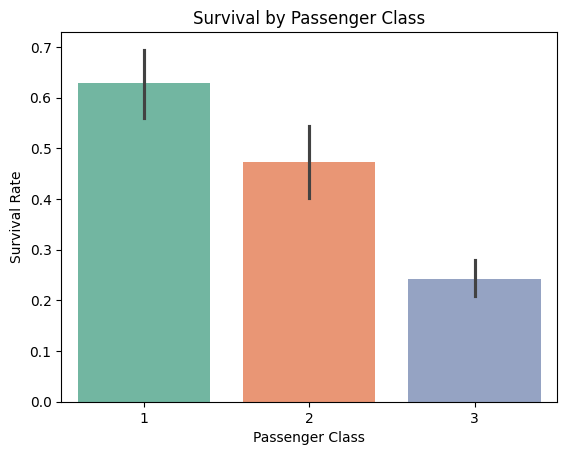

In [5]:
# Q7:-  Create a bar chart to show survival by passenger class.
sns.barplot(data=df, x='Pclass', y='Survived', palette='Set2')
plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

1st class passengers had the highest likelihood of survival, followed by 2nd class, while 3rd class passengers had the lowest survival rate.

     Survived  Pclass   Age  SibSp  Parch     Fare
0           0       3  22.0      1      0   7.2500
1           1       1  38.0      1      0  71.2833
2           1       3  26.0      0      0   7.9250
3           1       1  35.0      1      0  53.1000
4           0       3  35.0      0      0   8.0500
..        ...     ...   ...    ...    ...      ...
886         0       2  27.0      0      0  13.0000
887         1       1  19.0      0      0  30.0000
888         0       3   NaN      1      2  23.4500
889         1       1  26.0      0      0  30.0000
890         0       3  32.0      0      0   7.7500

[891 rows x 6 columns]


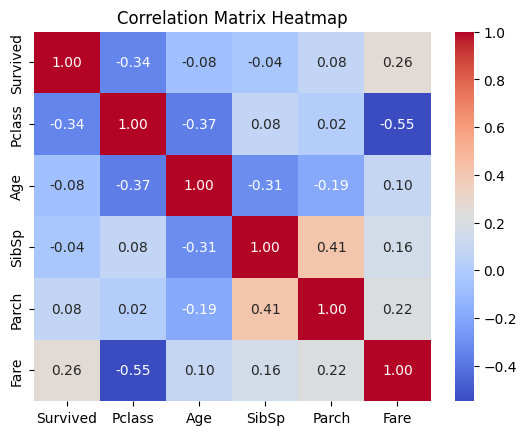

In [20]:
# q8:- Create a heatmap to show correlation between numerical variables.
# seperating  out the numeric columns for corerelation
numerical_df = df[["Survived","Pclass","Age","SibSp","Parch","Fare"]]
print(numerical_df)
sns.heatmap(numerical_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()


pclass has relatively negative  coerelation with  fare and survivedanf fare  has positive corelation with survival,also age has negative correlation with survival but has positive corelation with fare.

In [23]:
# Q9.Identify which passenger class paid the highest fare on average.
average_fare_by_class = df.groupby('Pclass')['Fare'].mean()
highest_average_fare_class = average_fare_by_class.idxmax()
print("the passenger class that paid the highest fare on average is:",highest_average_fare_class)

the passenger class that paid the highest fare on average is: 1


In [ ]:
# Q10. Write at least 5 insights from the dataset based on your visualizations.

5 insights are:-
1)  Females had a significantly higher survival rate than males.
2)passenger class has influenced the survival rate i.e the high class passeners had given priotity over oyher lower class  for survival.
3)titanic mostly has the adults of range(20-40) and
the overall  passenger counts reflects the dominance of males over  as they are more  in numbers than others.
4.) Most passengers traveled using very inexpensive tickets.
5) large families aremostly limited to cheaper tickets while while single passengers or couples bought the
luxury class tickets.
